## Basic LLM

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict, List, Union, Annotated, Sequence
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage, SystemMessage
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, START, END
import os
load_dotenv()

True

In [21]:
class AgentState(TypedDict):
    messages: List[HumanMessage]

In [22]:
model = ChatGoogleGenerativeAI(model = "gemini-3.5-flash-lite",
                                max_tokens = 512,
                                api_key = os.getenv("GOOGLE_API_KEY"))

In [23]:
def process(state: AgentState) -> AgentState:
    response = model.invoke(state["messages"])
    print(f"\nAI: {response.content}")
    return state

In [24]:
graph = StateGraph(AgentState)

graph.add_node("process", process)

graph.add_edge(START, "process")
graph.add_edge("process", END) 

agent = graph.compile()

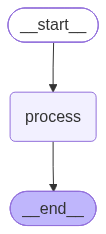

In [25]:
agent

In [ ]:
user_input = input("Enter: ")
while user_input != "exit":
    agent.invoke({"messages": [HumanMessage(content=user_input)]})
    user_input = input("Enter: ")


AI: [{'type': 'text', 'text': 'Nice to meet you, Bishoy! How can I help you today?', 'extras': {'signature': 'El4KXAERTTIPRNQ2stpOEB1WfzwsfPgbVHvnASwJA3AqF5/vT7oJe58vg0pA/B1arrcM24IQ2YT7fldnb2qXnx7B29F+HgWu24661Xr8ky0reJqTbjTeIj+tOKJzPIZ1'}}]

AI: [{'type': 'text', 'text': "I don't know your name. You haven't told me yet! Would you like to share it?", 'extras': {'signature': 'El4KXAERTTIPgZlTNYO4epj+hoRlHXpQVUJgjOnJ17DduBcaNEWL/b0ZCkS2bogkWHHPfnX6SPJbo/3fe3w7sjF3b9NLULhaObtdSkAV+GDPZsq2umWEYQm+8kCX7Zjl'}}]


## Memory Agent

In [27]:
class AgentState(TypedDict):
    messages: List[Union[HumanMessage, AIMessage]]

In [28]:
model = ChatGoogleGenerativeAI(model = "gemini-3.5-flash-lite",
                                max_tokens = 512,
                                api_key = os.getenv("GOOGLE_API_KEY"))

In [29]:
def process(state: AgentState) -> AgentState:
    """This node will solve the request you input"""
    response = model.invoke(state["messages"])
    state["messages"].append(AIMessage(content=response.content)) 
    print(f"\nAI: {response.content}")
    print("CURRENT STATE: ", state["messages"])
    return state

In [30]:
graph = StateGraph(AgentState)

graph.add_node("process", process)

graph.add_edge(START, "process")
graph.add_edge("process", END) 

agent = graph.compile()

In [31]:
conversation_history = []
user_input = input("Enter: ")
while user_input != "exit":
    conversation_history.append(HumanMessage(content=user_input))
    result = agent.invoke({"messages": conversation_history})
    conversation_history = result["messages"]
    user_input = input("Enter: ")


AI: [{'type': 'text', 'text': 'Nice to meet you, Bishoy! How can I help you today?', 'extras': {'signature': 'El4KXAERTTIPjt2QE9pTtHidLmncwu61se02CVc7B4Hd7Gevq7dbhXmWSf0l+XOrWm8vLVqLhAeMtPPyr97nvuQ3BvlwPXIKR0BkzzF61ZKWMdIDu0dTLG+2kmAg3QCX'}}]
CURRENT STATE:  [HumanMessage(content='my name is bishoy', additional_kwargs={}, response_metadata={}), AIMessage(content=[{'type': 'text', 'text': 'Nice to meet you, Bishoy! How can I help you today?', 'extras': {'signature': 'El4KXAERTTIPjt2QE9pTtHidLmncwu61se02CVc7B4Hd7Gevq7dbhXmWSf0l+XOrWm8vLVqLhAeMtPPyr97nvuQ3BvlwPXIKR0BkzzF61ZKWMdIDu0dTLG+2kmAg3QCX'}}], additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

AI: [{'type': 'text', 'text': 'Your name is Bishoy!', 'extras': {'signature': 'El4KXAERTTIPSU5mV+Pv2aMaDXp9ijnLtTIe0F4EW5U1s4gdjy5weJy2xKWKoSRepO/yn9jwUuuytRijLN970eEIqI8OLaXlsea7VHhD6qlPQxZ8xR2FpgZma3BSlbao'}}]
CURRENT STATE:  [HumanMessage(content='my name is bishoy', additional_kwargs={}, response_metadata

In [32]:
# with open("logging.txt", "w") as file:
#     file.write("Your Conversation Log:\n")
    
#     for message in conversation_history:
#         if isinstance(message, HumanMessage):
#             file.write(f"You: {message.content}\n")
#         elif isinstance(message, AIMessage):
#             file.write(f"AI: {message.content}\n\n")
#     file.write("End of Conversation")

# print("Conversation saved to logging.txt")

## ReAct Agent

In [35]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [39]:
model = ChatGoogleGenerativeAI(model = "gemini-3.5-flash-lite",
                                max_tokens = 512,
                                api_key = os.getenv("GOOGLE_API_KEY"))

In [41]:
@tool
def add(a: int, b:int):
    """This is an addition function that adds 2 numbers together"""
    return a + b

@tool
def subtract(a: int, b: int):
    """Subtraction function"""
    return a - b

@tool
def multiply(a: int, b: int):
    """Multiplication function"""
    return a * b

tools = [add, subtract, multiply]

In [42]:
model_with_tools = model.bind_tools(tools)

In [43]:
def model_call(state:AgentState) -> AgentState:
    system_prompt = SystemMessage(content=
        "You are my AI assistant, please answer my query to the best of your ability."
    )
    response = model_with_tools.invoke([system_prompt] + state["messages"])
    return {"messages": [response]}

In [44]:
def should_continue(state: AgentState): 
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls: 
        return "end"
    else:
        return "continue"

In [45]:
graph = StateGraph(AgentState)
graph.add_node("our_agent", model_call)


tool_node = ToolNode(tools=tools)
graph.add_node("tools", tool_node)

graph.set_entry_point("our_agent")

graph.add_conditional_edges(
    "our_agent",
    should_continue,
    {
        "continue": "tools",
        "end": END,
    },
)

graph.add_edge("tools", "our_agent")

app = graph.compile()

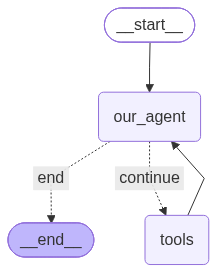

In [46]:
app

In [47]:
def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

In [48]:
inputs = {"messages": [("user", "Add 40 + 12 and then multiply the result by 6. Also tell me a joke please.")]}
print_stream(app.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Add 40 + 12 and then multiply the result by 6. Also tell me a joke please.
================================== Ai Message ==================================

[]
Tool Calls:
  add (call_5081773)
 Call ID: call_5081773
  Args:
    b: 12
    a: 40
================================= Tool Message =================================
Name: add

52
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (call_1318816)
 Call ID: call_1318816
  Args:
    b: 6
    a: 52
================================= Tool Message =================================
Name: multiply

312
================================== Ai Message ==================================

[{'type': 'text', 'text': "First, adding 40 and 12 gives you **52**. \nThen, multiplying that result by 6 gives you **312**.\n\nHere is a joke for you:\n\n**Why don't scientists trust atoms?**\nBecause they make up everythi